In [20]:
pwd()

"/home/nicholaswallace/Documents/projects/Polyhedron"

In [27]:
using Pkg
Pkg.activate(".")
Pkg.instantiate()
include("Polyhedron.jl")
using .Poly

  Activating project at `/mnt/Dados/Documents/Felipe/Estudo/bolsa/Polyhedron`


In [28]:
A = [0.9666 0;
    0.0328 0.9666] 
B = [0.1980;
    0.0033;;]

C = [0 1]

T = 0.5

delta = 0.5

A_exp = hcat(A, [0 0; 0 0])
A_exp = vcat(A_exp, [0 -T 1 T; 0 0 0 delta])

B_exp = vcat(B, [0;0])

E_exp = vcat(zeros(3), [1-delta])

Sx = [1/15 0
      0 1/15;
     -1/15 0;
      0 -1/15;]
Sv = [1/50;
      -1/50;]

Sw = [1/15;
      -1/15;]

Sx = vcat(Sx, zeros(4, 2))
Sv = vcat(vcat(zeros(4, 1), Sv) , zeros(2, 1))
Sw = vcat(zeros(6, 1), Sw)

S = hcat(hcat(Sx, Sv), Sw)

# Fr para a referência
R = [1/15;
      -1/15;;]
d = 2

2

testando variáveis

In [ ]:
A_exp

In [ ]:
B_exp

In [ ]:
E_exp

In [ ]:
S

In [ ]:
R

In [ ]:
result = Poly.finding_L_pinvariant_segref_delay(A_exp, B_exp, E_exp, S, R, d; lf=20)

Job 18613681 dispatched
password: OQICBUrZ
---------- Begin Solver Output -----------
Condor submit: 'neos.submit'
Condor submit: 'watchdog.submit'
Job submitted to NEOS HTCondor pool.



tentando achar um poliedro p-invariante w.t. x(k+1) = Ax(k) BGx(k-d) + Er(k) 

In [39]:
F = result["F"]

6×4 Matrix{Float64}:
  0.00110289  -0.0560888  -0.00175053   0.000824769
 -0.0383211   -0.0835434  -3.1103e-14  -0.136651
  0.0397725    0.261843   -0.0118082   -0.011876
  0.225591     0.170398   -0.00906886   5.04668e-14
 -0.0243287   -0.178076    0.0160696    0.0160712
 -0.210438    -0.126352    0.00537898   0.0398989

Achando o poliedro de cond. iniciais admissíveis e preparando os inputs para a trajetória.

In [17]:
F = [0.00110289  -0.0560888  -0.00175053   0.000824769;
 -0.0383211   -0.0835434  -3.1103e-14  -0.136651;
  0.0397725    0.261843   -0.0118082   -0.011876;
  0.225591     0.170398   -0.00906886   5.04668e-14;
 -0.0243287   -0.178076    0.0160696    0.0160712;
 -0.210438    -0.126352    0.00537898   0.0398989]

w = ones(size(F, 1))
nx = size(A_exp, 1)

passos = 100
r = ones(passos) * 10

G = [-1.00452 -0.92864 0.0489999 0.0488346;]
BG = B_exp * G

init_cond_F, init_cond_w = Poly.admissable_initCond(A_exp, BG, F, d, w; fixed_d=true)

ext_vertices_tuple = Poly.get_extVert_tuple(init_cond_F, init_cond_w, 2, nx)

traj1 = Poly.trajectory_segref_delay(ext_vertices_tuple, A_exp, BG, E_exp, r, passos, d; reverse=true)


101-element Vector{Tuple}:
 (-6.264695387143295, -8.413500567645725, -291.9345738739698, -0.4173956887809712)
 (-7.134358724760219, -8.355953393443784, -287.9365214345374, 4.791302155609515)
 (-6.9394377568401024, -8.311594293166346, -281.36289366001074, 7.395651077804757)
 (-6.4994835034494445, -8.258130984993743, -273.5092709745252, 8.697825538902379)
 (-6.032189550536189, -8.191322282276458, -265.0312927125771, 9.34891276945119)
 (-5.589051493004919, -8.111560219863623, -256.2611751867133, 9.674456384725595)
 (-5.1773921199807065, -8.020205246604776, -247.36816688441866, 9.837228192362797)
 (-4.794050734637164, -7.918641911427941, -238.43945016493487, 9.918614096181399)
 (-4.434333758905545, -7.808077540995768, -229.5208221611302, 9.9593070480907)
 (-4.09413734969273, -7.6895324040575215, -220.63712986658697, 9.97965352404535)
 ⋮
 (7.031695522725805, 4.328967600668856, 245.716942416744, 10.0)
 (7.08213838590003, 4.419774720845811, 248.55245861640955, 10.0)
 (7.131689192626376, 4.509

Achando a projeção e plotando o Poliedro no R² com a trajetória.

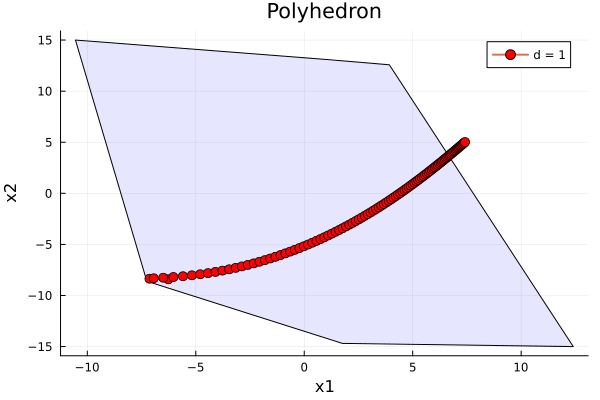

In [18]:
using Plots

F1 = F[:, 1:2]
F2 = F[:, 3:4]

T = Poly.poly_projection(F2)

Poly.plot_poly(T*F1, T*ones(size(F1, 1)))

x1 = [p[1] for p in traj1]
x2 = [p[2] for p in traj1]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 1",
     xlabel = "x1",
     ylabel = "x2")

Plotando os estados em função de k.

In [ ]:
# Plot x1 and x2 vs time step k
plot(k, x1_traj, label="x1", xlabel="k", ylabel="State value", legend=:best, linewidth=2, marker=:circle, markersize=3)
plot!(k, x2_traj, label="x2", linewidth=2, marker=:square, markersize=3)

In [ ]:
# Plot all states (x1, x2, v, w) vs time step k

# Extract all state components
x1_traj = [p[1] for p in traj1]
x2_traj = [p[2] for p in traj1]
v_traj = [p[3] for p in traj1]
w_traj = [p[4] for p in traj1]

# Time steps
k = 1:length(traj1)

# Create subplots for each state
p1 = plot(k, x1_traj, label="x1", xlabel="k", ylabel="x1", legend=:best, linewidth=2)
p2 = plot(k, x2_traj, label="x2", xlabel="k", ylabel="x2", legend=:best, linewidth=2)
p3 = plot(k, v_traj, label="v (integrated error)", xlabel="k", ylabel="v", legend=:best, linewidth=2)
p4 = plot(k, w_traj, label="w (filtered reference)", xlabel="k", ylabel="w", legend=:best, linewidth=2)

# Combine plots
plot(p1, p2, p3, p4, layout=(2,2), size=(1000, 800))